In [ ]:
!pip install numpy pandas scikit-learn tensorflow

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [41]:
data = pd.read_csv('./dataset/housing.csv')

data.isnull().sum()

data = data.fillna(data.mean())

In [43]:
# 2. Split features and target
X = data.drop("medv", axis=1)
y = data["medv"]

In [45]:
# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# 4. Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
# 5. Build Deep Neural Network
model = Sequential()

# Input layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output layer
model.add(Dense(1))

In [51]:
# 6.Compile Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 7. Train model
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)



Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 601.9247 - mae: 22.6568   
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 505.0708 - mae: 20.4173
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 377.9083 - mae: 16.8496 
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 206.3439 - mae: 11.6813
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - loss: 118.2375 - mae: 8.2719
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - loss: 54.9717 - mae: 5.7908
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 29.7385 - mae: 4.2035 
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 25.4153 - mae: 3.7567
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21.4974 - mae: 3.5634 
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21.2844 - mae: 3.4582 
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - loss: 21.4768 - mae: 3.4856
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21.9290 - mae: 3.6019 
Epoch 13

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------- LINEAR REGRESSION ----------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)

# ---------------- DNN ----------------
dnn_pred = model.predict(X_test).flatten()

dnn_mse = mean_squared_error(y_test, dnn_pred)
dnn_mae = mean_absolute_error(y_test, dnn_pred)

# ---------------- PRINT RESULTS ----------------
print("===== MODEL COMPARISON =====\n")

print("Linear Regression:")
print("MSE:", lr_mse)
print("MAE:", lr_mae)

print("\nDeep Neural Network:")
print("MSE:", dnn_mse)
print("MAE:", dnn_mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
===== MODEL COMPARISON =====

Linear Regression:
MSE: 24.404825188146468
MAE: 3.2064039639003847

Deep Neural Network:
MSE: 12.73201629428812
MAE: 2.466580634023629


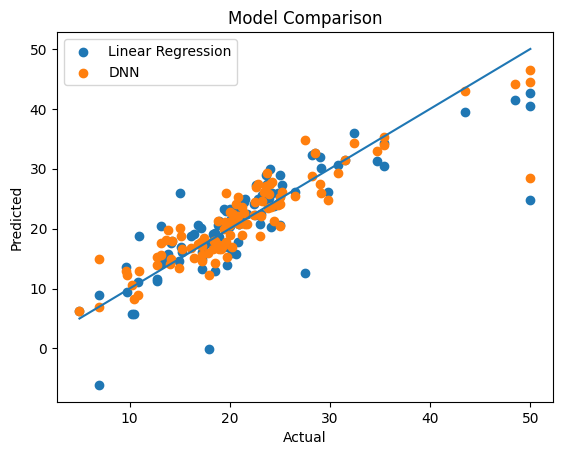

In [57]:
import matplotlib.pyplot as plt


plt.scatter(y_test, lr_pred, label='Linear Regression')
plt.scatter(y_test, dnn_pred, label='DNN')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()